# Weekend Funding Flip Analysis

**Question:** Do hyperliquid perpetual funding rates exhibit a predictable weekend pattern?
Does funding decay or flip negative on Sat/Sun vs Mon–Fri?

**Decision use:** If the pattern is significant and consistent, it informs entry/exit timing around weekends — avoid holding positions with marginal APR through weekends, or enter before weekend decay to capture mean-reversion.

**Scope:** hyperliquid only (24/7 crypto; TradFi equity venues have closure noise).  
**Data:** `data/loris_funding_history.csv` — hourly Loris snapshots.

In [22]:
# Cell 1 — Setup
import csv
import sys
import statistics
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

try:
    from scipy import stats as scipy_stats
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False
    print("scipy not available — will report Cohen's d effect size instead of p-values")

try:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import numpy as np
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib/numpy not available — skipping visualizations")

# Paths — notebook is in notebooks/, repo root is one level up
# __file__ is undefined in Jupyter kernels, so use a try/except
try:
    REPO_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    nb_dir = Path(".").resolve()
    # If running from repo root (e.g. nbconvert), data/ is here
    # If running from notebooks/, data/ is ../data/
    if (nb_dir / "data" / "loris_funding_history.csv").exists():
        REPO_ROOT = nb_dir
    else:
        REPO_ROOT = nb_dir.parent

CSV_PATH = REPO_ROOT / "data" / "loris_funding_history.csv"
REPORTS_DIR = REPO_ROOT / "docs" / "reports"

# Constants
VENUE = "hyperliquid"
LEGACY_CUTOFF = datetime(2026, 2, 1, tzinfo=timezone.utc)  # exclude mislabeled legacy rows
MIN_WEEKEND_OBS = 8
MIN_WEEKDAY_OBS = 16
ANNUALIZE = 3.0 * 365.0 * 100.0  # 8h rate → APR %
PVAL_THRESHOLD = 0.05
STABLE_DELTA_PCT = 5.0  # apr_delta < 5% APR = "stable"

DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

print(f"Repo root:  {REPO_ROOT}")
print(f"CSV path:   {CSV_PATH}")
print(f"CSV exists: {CSV_PATH.exists()}")
print(f"scipy available: {HAS_SCIPY}")
print(f"matplotlib available: {HAS_MPL}")

Repo root:  /Users/beannguyen/Development/OpenClawAgents/hip3-agent
CSV path:   /Users/beannguyen/Development/OpenClawAgents/hip3-agent/data/loris_funding_history.csv
CSV exists: True
scipy available: True
matplotlib available: True


In [23]:
# Cell 2 — Load & Filter
# Pattern reused from scripts/audit_loris_data.py::load_series()

# symbol -> list of (datetime, funding_8h_rate)
raw: dict[str, list[tuple[datetime, float]]] = defaultdict(list)

skipped_parse = 0
skipped_legacy = 0
loaded = 0

with open(CSV_PATH, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row["exchange"] != VENUE:
            continue
        try:
            ts = datetime.fromisoformat(row["timestamp_utc"].replace("Z", "+00:00"))
        except (ValueError, KeyError):
            skipped_parse += 1
            continue
        # Drop legacy mislabeled data
        if ts < LEGACY_CUTOFF:
            skipped_legacy += 1
            continue
        try:
            rate = float(row["funding_8h_rate"])
        except (ValueError, KeyError):
            skipped_parse += 1
            continue
        raw[row["symbol"]].append((ts, rate))
        loaded += 1

# Sort each series chronologically
for sym in raw:
    raw[sym].sort(key=lambda x: x[0])

print(f"Loaded {loaded:,} rows across {len(raw):,} hyperliquid symbols")
print(f"Skipped: {skipped_parse} parse errors, {skipped_legacy:,} legacy pre-{LEGACY_CUTOFF.date()} rows")
print(f"Date range: {min(r[0][0] for r in raw.values()).date()} → {max(r[-1][0] for r in raw.values()).date()}")

Loaded 141,921 rows across 141 hyperliquid symbols
Skipped: 0 parse errors, 37,170 legacy pre-2026-02-01 rows
Date range: 2026-02-01 → 2026-04-27


In [24]:
# Cell 3 — Segment into weekday / weekend buckets

# weekday: Mon-Fri (weekday() 0-4)
# weekend: Sat-Sun (weekday() 5-6)

weekday_rates: dict[str, list[float]] = {}
weekend_rates: dict[str, list[float]] = {}
dow_rates: dict[str, list[list[float]]] = {}  # symbol -> [Mon[], Tue[], ..., Sun[]]

for sym, series in raw.items():
    wd = [rate for ts, rate in series if ts.weekday() <= 4]
    we = [rate for ts, rate in series if ts.weekday() >= 5]
    weekday_rates[sym] = wd
    weekend_rates[sym] = we
    dow_rates[sym] = [[rate for ts, rate in series if ts.weekday() == d] for d in range(7)]

# Apply sample gates
qualified = [
    sym for sym in raw
    if len(weekend_rates[sym]) >= MIN_WEEKEND_OBS and len(weekday_rates[sym]) >= MIN_WEEKDAY_OBS
]

print(f"Total symbols: {len(raw):,}")
print(f"Qualified (>={MIN_WEEKEND_OBS} weekend obs, >={MIN_WEEKDAY_OBS} weekday obs): {len(qualified):,}")
print()
# Show sample counts for a few symbols
sample_preview = sorted(qualified, key=lambda s: len(weekend_rates[s]), reverse=True)[:5]
for sym in sample_preview:
    print(f"  {sym:>12}: weekday={len(weekday_rates[sym]):>3}  weekend={len(weekend_rates[sym]):>3}  total={len(raw[sym]):>4}")

Total symbols: 141
Qualified (>=8 weekend obs, >=16 weekday obs): 126

          AAVE: weekday=1322  weekend=497  total=1819
            0G: weekday=1322  weekend=497  total=1819
           MON: weekday=944  weekend=353  total=1297
          PNUT: weekday=944  weekend=353  total=1297
        PENDLE: weekday=944  weekend=353  total=1297


In [25]:
# Cell 4 — Per-symbol statistics

def annualize(rate: float) -> float:
    return rate * ANNUALIZE

def mean_apr(rates: list[float]) -> float:
    return statistics.mean(rates) * ANNUALIZE if rates else float("nan")

def median_apr(rates: list[float]) -> float:
    return statistics.median(rates) * ANNUALIZE if rates else float("nan")

def std_apr(rates: list[float]) -> float:
    return statistics.stdev(rates) * ANNUALIZE if len(rates) >= 2 else float("nan")

def pos_rate(rates: list[float]) -> float:
    return 100.0 * sum(1 for r in rates if r > 0) / len(rates) if rates else float("nan")

def cohens_d(a: list[float], b: list[float]) -> float:
    if len(a) < 2 or len(b) < 2:
        return float("nan")
    pooled_std = ((statistics.variance(a) + statistics.variance(b)) / 2) ** 0.5
    return (statistics.mean(a) - statistics.mean(b)) / pooled_std if pooled_std > 0 else 0.0

results = []

for sym in qualified:
    wd = weekday_rates[sym]
    we = weekend_rates[sym]

    m_wd = mean_apr(wd)
    m_we = mean_apr(we)
    med_wd = median_apr(wd)
    med_we = median_apr(we)
    std_wd = std_apr(wd)
    std_we = std_apr(we)
    pr_wd = pos_rate(wd)
    pr_we = pos_rate(we)
    apr_delta = m_wd - m_we  # positive = weekday higher than weekend
    flip_risk = (pr_we < 50.0) and (pr_wd >= 60.0)

    if HAS_SCIPY:
        try:
            stat, pval = scipy_stats.mannwhitneyu(wd, we, alternative="two-sided")
            significant = pval < PVAL_THRESHOLD
        except Exception:
            pval = float("nan")
            significant = False
    else:
        pval = float("nan")
        significant = abs(cohens_d(wd, we)) > 0.5  # medium effect fallback

    effect = cohens_d(wd, we)

    results.append({
        "symbol": sym,
        "n_weekday": len(wd),
        "n_weekend": len(we),
        "mean_wd_apr": m_wd,
        "mean_we_apr": m_we,
        "median_wd_apr": med_wd,
        "median_we_apr": med_we,
        "std_wd": std_wd,
        "std_we": std_we,
        "pos_rate_wd": pr_wd,
        "pos_rate_we": pr_we,
        "apr_delta": apr_delta,
        "flip_risk": flip_risk,
        "pval": pval,
        "significant": significant,
        "cohens_d": effect,
    })

results.sort(key=lambda r: r["apr_delta"], reverse=True)
print(f"Per-symbol stats computed for {len(results)} symbols")
n_sig = sum(1 for r in results if r["significant"])
n_flip = sum(1 for r in results if r["flip_risk"])
print(f"Significant weekend effect (p<{PVAL_THRESHOLD}): {n_sig}/{len(results)}")
print(f"Flip risk (pos_rate_we<50% & pos_rate_wd>=60%): {n_flip}")

Per-symbol stats computed for 126 symbols
Significant weekend effect (p<0.05): 81/126
Flip risk (pos_rate_we<50% & pos_rate_wd>=60%): 5


In [26]:
# Cell 5 — Statistical significance summary

from datetime import datetime as _dt
now_str = _dt.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")

def fmt_pval(p: float) -> str:
    if p != p:  # nan
        return "n/a"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

def flip_icon(r: dict) -> str:
    return "FLIP" if r["flip_risk"] else ""

# ── Overall summary ──────────────────────────────────────────────────────────
print(f"="*72)
print(f"  WEEKEND FUNDING FLIP ANALYSIS")
print(f"  Generated: {now_str}  |  Venue: {VENUE}  |  N symbols: {len(results)}")
print(f"="*72)
print()
n_decay = sum(1 for r in results if r["significant"] and r["apr_delta"] > 0)
n_boost = sum(1 for r in results if r["significant"] and r["apr_delta"] < 0)
n_stable_all = sum(1 for r in results if abs(r["apr_delta"]) < STABLE_DELTA_PCT)
print(f"Significant weekend DECAY  (p<{PVAL_THRESHOLD}, WD>WE): {n_decay}/{len(results)}")
print(f"Significant weekend BOOST  (p<{PVAL_THRESHOLD}, WE>WD): {n_boost}/{len(results)}")
print(f"Flip risk (weekend pos_rate<50%, weekday>=60%):  {n_flip}/{len(results)}")
print(f"Stable weekend pattern (|delta|<{STABLE_DELTA_PCT}% APR):  {n_stable_all}/{len(results)}")
print()

# Mean across all symbols
all_deltas = [r["apr_delta"] for r in results]
print(f"Avg APR delta (WD − WE) across all: {statistics.mean(all_deltas):+.1f}%")
print(f"Median APR delta:                    {statistics.median(all_deltas):+.1f}%")
print(f"% symbols where weekday > weekend:   {100*sum(1 for d in all_deltas if d>0)/len(all_deltas):.0f}%")

  WEEKEND FUNDING FLIP ANALYSIS
  Generated: 2026-04-27 02:47 UTC  |  Venue: hyperliquid  |  N symbols: 126

Significant weekend DECAY  (p<0.05, WD>WE): 63/126
Significant weekend BOOST  (p<0.05, WE>WD): 18/126
Flip risk (weekend pos_rate<50%, weekday>=60%):  5/126
Stable weekend pattern (|delta|<5.0% APR):  66/126

Avg APR delta (WD − WE) across all: +6.1%
Median APR delta:                    +1.1%
% symbols where weekday > weekend:   64%


In [27]:
# Cell 6 — Day-of-week breakdown (top 15 by |apr_delta|)

top_symbols = sorted(results, key=lambda r: abs(r["apr_delta"]), reverse=True)[:15]
top_syms = [r["symbol"] for r in top_symbols]

print("Day-of-week mean APR % for top symbols (by |weekday−weekend delta|)")
print()
header = f"{'Symbol':>12} | " + " | ".join(f"{d:>6}" for d in DAY_NAMES) + " | delta(WD-WE)"
print(header)
print("-" * len(header))

dow_table = []  # for heatmap
for sym in top_syms:
    day_means = []
    for d in range(7):
        rates = dow_rates[sym][d]
        day_means.append(mean_apr(rates) if rates else float("nan"))
    dow_table.append((sym, day_means))
    vals = " | ".join(f"{v:>+6.1f}" if v == v else f"{'N/A':>6}" for v in day_means)
    r = next(x for x in results if x["symbol"] == sym)
    print(f"{sym:>12} | {vals} | {r['apr_delta']:+.1f}%")

Day-of-week mean APR % for top symbols (by |weekday−weekend delta|)

      Symbol |    Mon |    Tue |    Wed |    Thu |    Fri |    Sat |    Sun | delta(WD-WE)
------------------------------------------------------------------------------------------
       TURBO | -236.8 |  -74.2 |  -32.3 | -222.0 |   -0.8 | -1283.0 | -656.7 | +567.0%
        BLUR |  -35.2 |  -15.1 | -735.2 | -774.4 | -144.4 |  -21.4 |  -24.9 | -364.8%
         SKR |  -29.7 | -921.4 | -316.6 | -148.0 | -226.6 | -136.2 | -100.4 | -209.7%
         IMX |    N/A |    N/A |   +6.6 |    N/A |    N/A |  +11.0 | -227.8 | +205.7%
       AZTEC | -245.6 | -111.4 |  -61.6 |  -46.9 | -1510.9 | -645.3 | -442.7 | +181.1%
        CHIP |  +11.0 |    N/A |  -57.0 | -419.7 |  -69.0 |  +21.0 |  -46.4 | -169.1%
      RESOLV | -203.7 |  -82.9 |  -22.3 |   -9.3 |   +3.4 |   -3.9 | -433.6 | +161.8%
      STABLE | -217.2 | -171.3 | -189.2 | -290.2 | -193.6 | -129.3 |  -80.2 | -112.6%
       ANIME |  -93.0 |  -77.4 | -857.5 |  -35.3 |  -16.1 |

In [28]:
# Cell 7 — Summary tables

def print_table(title: str, rows: list[dict], max_rows: int = 30) -> None:
    print(f"\n{'─'*90}")
    print(f"  {title}")
    print(f"{'─'*90}")
    if not rows:
        print("  (none)")
        return
    hdr = (
        f"{'#':>3}  {'Symbol':>10}  {'WD APR':>8}  {'WE APR':>8}  "
        f"{'Delta':>7}  {'pos% WD':>7}  {'pos% WE':>7}  {'p-val':>7}  {'CohenD':>7}  {'Flag':>6}"
    )
    print(hdr)
    print("  " + "-" * (len(hdr) - 2))
    for i, r in enumerate(rows[:max_rows], 1):
        flag = "FLIP" if r["flip_risk"] else ""
        cd = f"{r['cohens_d']:+.2f}" if r["cohens_d"] == r["cohens_d"] else " nan"
        print(
            f"{i:>3}  {r['symbol']:>10}  {r['mean_wd_apr']:>+8.1f}  {r['mean_we_apr']:>+8.1f}  "
            f"{r['apr_delta']:>+7.1f}  {r['pos_rate_wd']:>7.0f}%  {r['pos_rate_we']:>7.0f}%  "
            f"{fmt_pval(r['pval']):>7}  {cd:>7}  {flag:>6}"
        )

# Table 1: Significant weekend decay (WD > WE)
decay_rows = [r for r in results if r["significant"] and r["apr_delta"] > 0]
decay_rows.sort(key=lambda r: r["apr_delta"], reverse=True)
print_table("Significant Weekend DECAY (p<0.05, weekday APR > weekend APR)", decay_rows)

# Table 2: Flip risk symbols
flip_rows = [r for r in results if r["flip_risk"]]
flip_rows.sort(key=lambda r: r["pos_rate_we"])
print_table("Flip Risk Symbols (weekend pos_rate < 50%, weekday >= 60%)", flip_rows)

# Table 3: Stable (abs delta < 5%)
stable_rows = [r for r in results if abs(r["apr_delta"]) < STABLE_DELTA_PCT]
stable_rows.sort(key=lambda r: r["mean_wd_apr"], reverse=True)
print_table(f"Stable Weekend Pattern (|WD−WE delta| < {STABLE_DELTA_PCT}% APR)", stable_rows[:20])

# Table 4: Significant weekend BOOST (rare, but worth knowing)
boost_rows = [r for r in results if r["significant"] and r["apr_delta"] < 0]
boost_rows.sort(key=lambda r: r["apr_delta"])
print_table("Significant Weekend BOOST (p<0.05, weekend APR > weekday APR)", boost_rows)


──────────────────────────────────────────────────────────────────────────────────────────
  Significant Weekend DECAY (p<0.05, weekday APR > weekend APR)
──────────────────────────────────────────────────────────────────────────────────────────
  #      Symbol    WD APR    WE APR    Delta  pos% WD  pos% WE    p-val   CohenD    Flag
  --------------------------------------------------------------------------------------
  1       TURBO    -163.3    -730.3   +567.0       19%        0%   <0.001    +1.63        
  2         IMX      +6.6    -199.1   +205.7       79%       12%   <0.001    +1.42    FLIP
  3       AZTEC    -362.9    -544.0   +181.1       42%       17%   <0.001    +0.13        
  4       ANIME    -216.2    -327.2   +111.0       13%        0%   <0.001    +0.27        
  5        BERA     -53.1    -121.6    +68.6       44%       19%   <0.001    +0.31        
  6       TRUMP     -47.7    -110.4    +62.7       17%        5%   <0.001    +0.73        
  7          ZK      -3.4    

/var/folders/3k/xpx1wc417334m55s9k9vtyb00000gn/T/ipykernel_184/3328856990.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(


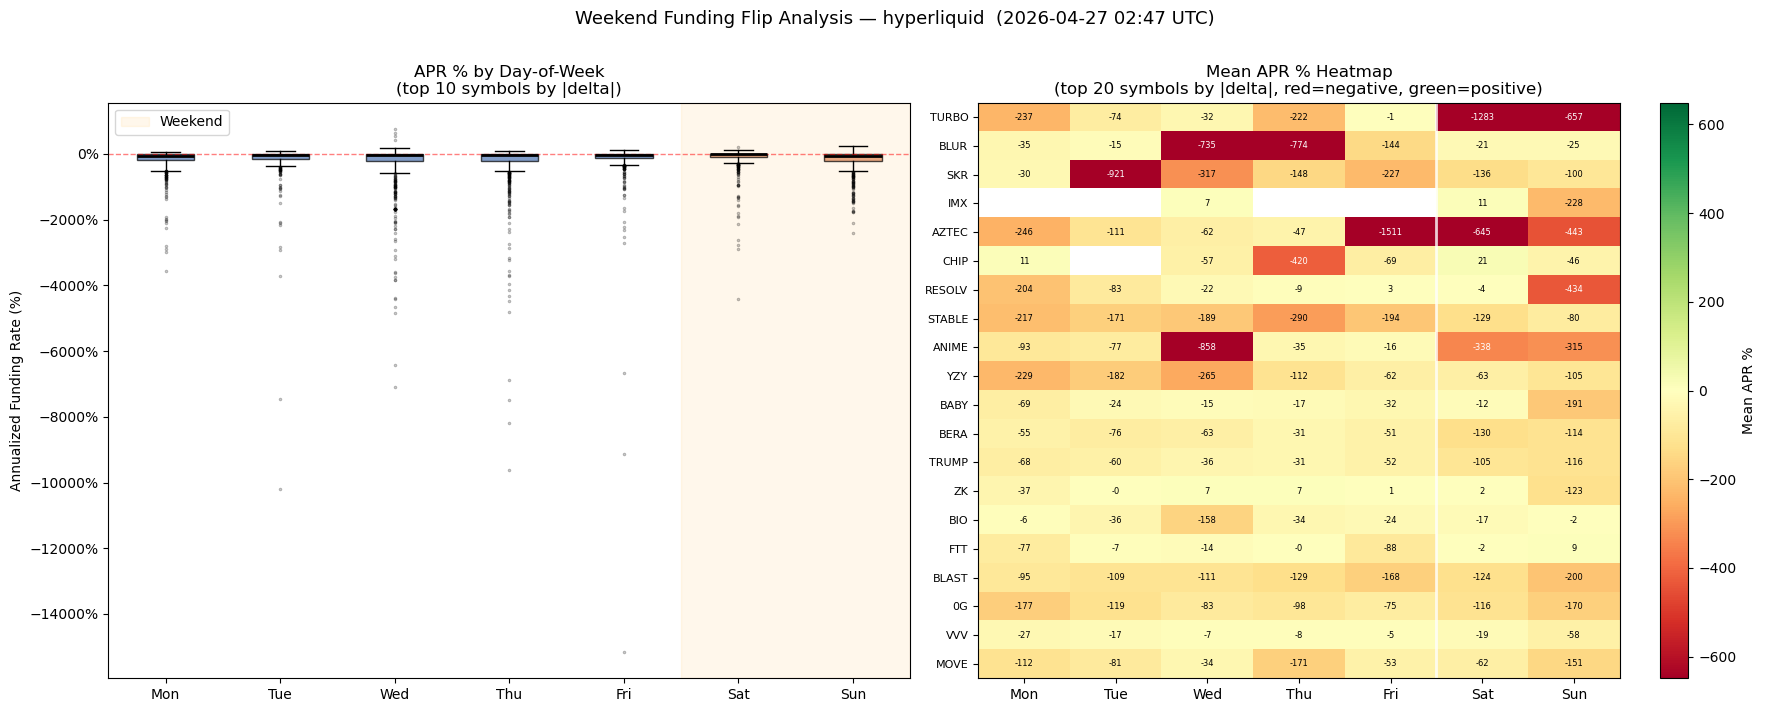

Saved: /Users/beannguyen/Development/OpenClawAgents/hip3-agent/docs/reports/weekend_funding_heatmap.png


In [29]:
# Cell 8 — Visualizations (requires matplotlib + numpy)

if not HAS_MPL:
    print("matplotlib not available — skipping visualizations")
else:
    import numpy as np

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f"Weekend Funding Flip Analysis — hyperliquid  ({now_str})", fontsize=13, y=1.01)

    # ── Plot 1: Box plot — APR by day-of-week (top 10 by |delta|) ──────────
    ax1 = axes[0]
    top10_syms = [r["symbol"] for r in sorted(results, key=lambda r: abs(r["apr_delta"]), reverse=True)[:10]]

    dow_data = [[] for _ in range(7)]
    for sym in top10_syms:
        for d in range(7):
            rates = dow_rates[sym][d]
            if rates:
                dow_data[d].extend([r * ANNUALIZE for r in rates])

    colors = ["#4C72B0"] * 5 + ["#DD8452", "#DD8452"]  # blue weekday, orange weekend
    bp = ax1.boxplot(
        dow_data,
        labels=DAY_NAMES,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker=".", alpha=0.3, markersize=3),
        whiskerprops=dict(linewidth=1),
        boxprops=dict(linewidth=1),
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax1.axhline(0, color="red", linestyle="--", alpha=0.5, linewidth=1)
    ax1.axvspan(5.5, 7.5, alpha=0.08, color="orange", label="Weekend")
    ax1.set_title(f"APR % by Day-of-Week\n(top 10 symbols by |delta|)")
    ax1.set_ylabel("Annualized Funding Rate (%)")
    ax1.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0, symbol="%"))
    ax1.legend()

    # ── Plot 2: Heatmap — symbols × day-of-week ──────────────────────────
    ax2 = axes[1]
    hm_syms = [r["symbol"] for r in sorted(results, key=lambda r: abs(r["apr_delta"]), reverse=True)[:20]]
    matrix = []
    for sym in hm_syms:
        row_vals = []
        for d in range(7):
            rates = dow_rates[sym][d]
            row_vals.append(statistics.mean(rates) * ANNUALIZE if rates else float("nan"))
        matrix.append(row_vals)

    mat_np = np.array(matrix, dtype=float)
    vmax = np.nanpercentile(np.abs(mat_np), 95)
    im = ax2.imshow(mat_np, aspect="auto", cmap="RdYlGn", vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax2, label="Mean APR %")

    ax2.set_xticks(range(7))
    ax2.set_xticklabels(DAY_NAMES)
    ax2.set_yticks(range(len(hm_syms)))
    ax2.set_yticklabels(hm_syms, fontsize=8)
    ax2.axvline(4.5, color="white", linewidth=2, alpha=0.8)  # weekday/weekend boundary
    ax2.set_title("Mean APR % Heatmap\n(top 20 symbols by |delta|, red=negative, green=positive)")

    for i in range(len(hm_syms)):
        for j in range(7):
            val = mat_np[i, j]
            if not np.isnan(val):
                ax2.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=6,
                         color="white" if abs(val) > vmax * 0.5 else "black")

    plt.tight_layout()
    out_path = REPORTS_DIR / "weekend_funding_heatmap.png"
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(str(out_path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

In [30]:
# Cell 9 — Trading Implications & Decision Framework

print("="*72)
print("  TRADING IMPLICATIONS")
print("="*72)
print()

# Identify high-priority flip-risk symbols that are likely in active universe
# (high weekday APR + flip risk)
actionable = [
    r for r in results
    if r["flip_risk"] and r["mean_wd_apr"] > 20.0  # above candidate floor
]
actionable.sort(key=lambda r: r["mean_wd_apr"], reverse=True)

if actionable:
    print(f"HIGH PRIORITY — Flip Risk symbols above 20% APR floor ({len(actionable)} symbols):")
    print("  These are candidates worth holding weekday but risky to hold through weekends.")
    print()
    for r in actionable:
        print(f"  {r['symbol']:>12}: WD {r['mean_wd_apr']:>+6.1f}% → WE {r['mean_we_apr']:>+6.1f}% APR  "
              f"(pos% WD={r['pos_rate_wd']:.0f}%, WE={r['pos_rate_we']:.0f}%)")
else:
    print("  No actionable flip-risk symbols above 20% APR floor found.")

print()

# Weekend decay rule-of-thumb
if all_deltas:
    avg_delta = statistics.mean(all_deltas)
    pct_wd_higher = 100 * sum(1 for d in all_deltas if d > 0) / len(all_deltas)
    print(f"AGGREGATE PATTERN:")
    print(f"  {pct_wd_higher:.0f}% of symbols have higher APR on weekdays vs weekends")
    print(f"  Average weekday premium: {avg_delta:+.1f}% APR")
    print()
    if pct_wd_higher > 65:
        print("  VERDICT: Weekend decay is a real, broad pattern on hyperliquid.")
        print("  Consider: close marginal positions (APR near floor) before weekends.")
        print("  Consider: hold strong positions (APR >>floor) through weekends — decay is partial.")
    elif pct_wd_higher > 50:
        print("  VERDICT: Mild weekend tendency. Not strong enough to trade systematically.")
        print("  Only act on flip-risk symbols; ignore for strong >50% APR positions.")
    else:
        print("  VERDICT: No consistent weekend pattern. Weekend timing is not a factor.")

print()
print(f"Weekend fee drag estimate (round-trip at 0.035% taker × 2 legs × 2 venues):")
print(f"  ~0.14% of notional per round-trip.")
print(f"  At $50k position: ~$70/cycle. Break-even requires >{0.14*365/2:.0f}% net APR to justify Friday close.")
print(f"  Rule of thumb: only close/reopen for weekend if expected loss > $70 (= ~{0.14*365/2:.0f}% APR on $50k).")

  TRADING IMPLICATIONS

  No actionable flip-risk symbols above 20% APR floor found.

AGGREGATE PATTERN:
  64% of symbols have higher APR on weekdays vs weekends
  Average weekday premium: +6.1% APR

  VERDICT: Mild weekend tendency. Not strong enough to trade systematically.
  Only act on flip-risk symbols; ignore for strong >50% APR positions.

Weekend fee drag estimate (round-trip at 0.035% taker × 2 legs × 2 venues):
  ~0.14% of notional per round-trip.
  At $50k position: ~$70/cycle. Break-even requires >26% net APR to justify Friday close.
  Rule of thumb: only close/reopen for weekend if expected loss > $70 (= ~26% APR on $50k).


---

## Part 2: Felix Equity Perps (xyz / flx / kinetiq venues)

**Venue mapping in perp markets:**
- `tradexyz` → `xyz:SYMBOL`
- `felix` → `flx:SYMBOL`
- `kinetiq` → `kinetiq:SYMBOL`

**Note:** Equity underlying markets are closed on weekends. Venues still record funding 24/7 (~27% of observations fall on Sat/Sun), but the funding dynamics shift because there is no price discovery from the equity market. This typically causes:
1. Funding to drain or flip negative (shorts overhang, longs exit)
2. Basis to widen unpredictably (no spot reference)

This section uses `data/felix_equities_cache.json` as the symbol universe and filters to active (non-stale) pairs only.

In [31]:
# Cell 10 — Load equity venue data
import json

EQUITY_VENUES = {"felix", "tradexyz", "kinetiq"}

# Venue short-name for display (matches perp market notation)
VENUE_PREFIX = {
    "tradexyz": "xyz",
    "felix": "flx",
    "kinetiq": "kinetiq",
}

# Load felix equity symbol universe
felix_cache_path = REPO_ROOT / "data" / "felix_equities_cache.json"
with open(felix_cache_path) as f:
    felix_equity_syms = set(json.load(f)["symbols"])

# Known dead pairs (stale > 1 week as of last audit — confirmed delisted)
DEAD_EQUITY_PAIRS = {
    "tradexyz:AAPL", "tradexyz:META", "tradexyz:MU", "tradexyz:TSM",
    "kinetiq:AAPL", "kinetiq:MU",
}

eq_series: dict[tuple[str, str], list[tuple[datetime, float]]] = defaultdict(list)
skipped_dead = 0

with open(CSV_PATH, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        exch, sym = row["exchange"], row["symbol"]
        pair_key = f"{exch}:{sym}"
        if exch not in EQUITY_VENUES:
            continue
        if sym not in felix_equity_syms:
            continue
        if pair_key in DEAD_EQUITY_PAIRS:
            skipped_dead += 1
            continue
        try:
            ts = datetime.fromisoformat(row["timestamp_utc"].replace("Z", "+00:00"))
            rate = float(row["funding_8h_rate"])
        except (ValueError, KeyError):
            continue
        eq_series[(exch, sym)].append((ts, rate))

for k in eq_series:
    eq_series[k].sort(key=lambda x: x[0])

# Day-of-week breakdown per pair
eq_dow_rates: dict[tuple, list[list[float]]] = {}
for (exch, sym), pts in eq_series.items():
    eq_dow_rates[(exch, sym)] = [[r for ts, r in pts if ts.weekday() == d] for d in range(7)]

eq_qualified = [
    k for k in eq_series
    if len([r for ts, r in eq_series[k] if ts.weekday() >= 5]) >= MIN_WEEKEND_OBS
    and len([r for ts, r in eq_series[k] if ts.weekday() <= 4]) >= MIN_WEEKDAY_OBS
]

print(f"Equity venue pairs loaded: {len(eq_series)}  (skipped dead: {skipped_dead // 100}+ rows)")
print(f"Qualified for analysis (≥{MIN_WEEKEND_OBS} WE, ≥{MIN_WEEKDAY_OBS} WD): {len(eq_qualified)}")
print()
for (exch, sym) in sorted(eq_qualified, key=lambda k: k[0]+":"+k[1]):
    pts = eq_series[(exch, sym)]
    we_n = sum(1 for ts, _ in pts if ts.weekday() >= 5)
    wd_n = sum(1 for ts, _ in pts if ts.weekday() <= 4)
    last_apr = pts[-1][1] * ANNUALIZE
    stale_h = (datetime.now(timezone.utc) - pts[-1][0]).total_seconds() / 3600
    prefix = VENUE_PREFIX[exch]
    print(f"  {prefix}:{sym:<8}  n={len(pts):>4}  WD={wd_n:>3}  WE={we_n:>3}  last={pts[-1][0].strftime('%Y-%m-%d')}  APR={last_apr:>+7.1f}%  {'STALE!' if stale_h>12 else 'fresh'}")

Equity venue pairs loaded: 28  (skipped dead: 42+ rows)
Qualified for analysis (≥8 WE, ≥16 WD): 28

  flx:CRCL      n=1367  WD=996  WE=371  last=2026-04-27  APR=   +0.0%  fresh
  flx:NVDA      n= 977  WD=713  WE=264  last=2026-04-27  APR=   +0.0%  fresh
  flx:TSLA      n=1367  WD=996  WE=371  last=2026-04-27  APR=   +0.0%  fresh
  kinetiq:BABA      n=1360  WD=989  WE=371  last=2026-04-27  APR=  -30.6%  fresh
  kinetiq:BMNR      n=1133  WD=822  WE=311  last=2026-04-27  APR=   +5.0%  fresh
  kinetiq:GOOGL     n= 636  WD=426  WE=210  last=2026-04-27  APR=   +5.0%  fresh
  kinetiq:NVDA      n= 855  WD=627  WE=228  last=2026-04-27  APR=   +5.0%  fresh
  kinetiq:RTX       n=1109  WD=810  WE=299  last=2026-04-27  APR= +170.0%  fresh
  kinetiq:TSLA      n=1360  WD=989  WE=371  last=2026-04-27  APR=   +5.0%  fresh
  xyz:AMD       n=1365  WD=994  WE=371  last=2026-04-27  APR=  +21.5%  fresh
  xyz:AMZN      n= 118  WD= 70  WE= 48  last=2026-04-27  APR=  +44.6%  fresh
  xyz:BABA      n=1365  WD=99

In [32]:
# Cell 11 — Equity weekend stats + ranked tables

eq_results = []

for (exch, sym) in eq_qualified:
    pts = eq_series[(exch, sym)]
    wd = [r for ts, r in pts if ts.weekday() <= 4]
    we = [r for ts, r in pts if ts.weekday() >= 5]

    m_wd = statistics.mean(wd) * ANNUALIZE
    m_we = statistics.mean(we) * ANNUALIZE
    pr_wd = 100.0 * sum(1 for r in wd if r > 0) / len(wd)
    pr_we = 100.0 * sum(1 for r in we if r > 0) / len(we)
    apr_delta = m_wd - m_we
    flip_risk = (pr_we < 50.0) and (pr_wd >= 60.0)

    if HAS_SCIPY:
        try:
            _, pval = scipy_stats.mannwhitneyu(wd, we, alternative="two-sided")
            significant = pval < PVAL_THRESHOLD
        except Exception:
            pval = float("nan"); significant = False
    else:
        pval = float("nan"); significant = False

    last_apr = pts[-1][1] * ANNUALIZE
    dow_means = []
    for d in range(7):
        rates = eq_dow_rates[(exch, sym)][d]
        dow_means.append(statistics.mean(rates) * ANNUALIZE if rates else float("nan"))

    prefix = VENUE_PREFIX[exch]
    eq_results.append({
        "pair": f"{prefix}:{sym}",
        "raw_pair": (exch, sym),
        "exch": exch, "sym": sym,
        "n_wd": len(wd), "n_we": len(we),
        "mean_wd": m_wd, "mean_we": m_we,
        "pr_wd": pr_wd, "pr_we": pr_we,
        "apr_delta": apr_delta,
        "flip_risk": flip_risk,
        "pval": pval, "significant": significant,
        "last_apr": last_apr,
        "dow_means": dow_means,
    })

eq_results.sort(key=lambda r: r["mean_wd"], reverse=True)

print("=" * 90)
print("  EQUITY PERP WEEKEND ANALYSIS  (xyz / flx / kinetiq venues)")
print("=" * 90)
print()
eq_n_sig = sum(1 for r in eq_results if r["significant"])
eq_n_flip = sum(1 for r in eq_results if r["flip_risk"])
eq_deltas = [r["apr_delta"] for r in eq_results]
pct_wd_higher_eq = 100 * sum(1 for d in eq_deltas if d > 0) / len(eq_deltas) if eq_deltas else 0
print(f"  {len(eq_results)} pairs analyzed  |  Significant p<0.05: {eq_n_sig}  |  Flip risk: {eq_n_flip}")
print(f"  % pairs WD APR > WE APR: {pct_wd_higher_eq:.0f}%")
print(f"  Avg delta (WD−WE):       {statistics.mean(eq_deltas):+.1f}% APR")
print(f"  Median delta:            {statistics.median(eq_deltas):+.1f}% APR")
print()

# Full table
hdr = f"{'Pair':>18}  {'WD APR':>8}  {'WE APR':>8}  {'Delta':>7}  {'pos%WD':>6}  {'pos%WE':>6}  {'p-val':>7}  {'Sig':>3}  {'Flip':>4}  {'CurrAPR':>8}"
print(hdr)
print("  " + "-" * (len(hdr) - 2))
for r in eq_results:
    pv = f"{r['pval']:.3f}" if r["pval"] > 0.001 else "<.001"
    pv = "n/a" if r["pval"] != r["pval"] else pv
    print(
        f"{r['pair']:>18}  {r['mean_wd']:>+8.1f}  {r['mean_we']:>+8.1f}  {r['apr_delta']:>+7.1f}  "
        f"{r['pr_wd']:>6.0f}%  {r['pr_we']:>6.0f}%  {pv:>7}  {'*' if r['significant'] else '':>3}  "
        f"{'Y' if r['flip_risk'] else '':>4}  {r['last_apr']:>+8.1f}%"
    )

# Day-of-week table
print()
print("Day-of-week breakdown:")
header_dow = f"{'Pair':>18} | " + " | ".join(f"{d:>6}" for d in DAY_NAMES)
print(header_dow)
print("-" * len(header_dow))
for r in eq_results:
    vals = " | ".join(f"{v:>+6.1f}" if v == v else f"{'N/A':>6}" for v in r["dow_means"])
    print(f"{r['pair']:>18} | {vals}")

  EQUITY PERP WEEKEND ANALYSIS  (xyz / flx / kinetiq venues)

  28 pairs analyzed  |  Significant p<0.05: 21  |  Flip risk: 9
  % pairs WD APR > WE APR: 93%
  Avg delta (WD−WE):       +22.4% APR
  Median delta:            +15.4% APR

              Pair    WD APR    WE APR    Delta  pos%WD  pos%WE    p-val  Sig  Flip   CurrAPR
  -------------------------------------------------------------------------------------------
          xyz:HIMS     +54.0     +49.7     +4.3      61%      61%    0.053                -15.8%
          xyz:RIVN     +22.7     -10.5    +33.2      82%      63%    <.001    *           +93.7%
       kinetiq:RTX     +18.3     -63.9    +82.1      67%      30%    <.001    *     Y    +170.0%
          xyz:CRCL     +15.3     -19.5    +34.8      92%      52%    <.001    *            -0.5%
          xyz:COST     +14.6     +11.5     +3.1      43%      44%    0.991                +19.9%
          xyz:HOOD     +12.8      +5.9     +6.9      97%      75%    0.713                +37

In [33]:
# Cell 12 — Equity trading implications

print("=" * 72)
print("  EQUITY PERP — TRADING IMPLICATIONS")
print("=" * 72)
print()

# HIGH PRIORITY: flip risk above 10% APR floor (equities have lower floor — thinner)
eq_actionable = [r for r in eq_results if r["flip_risk"] and r["mean_wd"] > 10.0]
eq_actionable.sort(key=lambda r: r["apr_delta"], reverse=True)

if eq_actionable:
    print(f"FLIP RISK — hold weekdays, CLOSE FRIDAY before weekend ({len(eq_actionable)} pairs):")
    print()
    for r in eq_actionable:
        print(f"  {r['pair']:>18}: WD {r['mean_wd']:>+6.1f}% → WE {r['mean_we']:>+6.1f}%  "
              f"(pos%: {r['pr_wd']:.0f}% → {r['pr_we']:.0f}%  |  delta={r['apr_delta']:>+.1f}%)")

print()

# WARNING: significant decay (not full flip, but meaningful)
eq_decay_warn = [r for r in eq_results if r["significant"] and r["apr_delta"] > 15.0 and not r["flip_risk"]]
eq_decay_warn.sort(key=lambda r: r["apr_delta"], reverse=True)
if eq_decay_warn:
    print(f"SIGNIFICANT DECAY — not flip, but material weekend reduction ({len(eq_decay_warn)} pairs):")
    print()
    for r in eq_decay_warn:
        print(f"  {r['pair']:>18}: WD {r['mean_wd']:>+6.1f}% → WE {r['mean_we']:>+6.1f}%  "
              f"(delta={r['apr_delta']:>+.1f}%)  pos%: {r['pr_wd']:.0f}%→{r['pr_we']:.0f}%")

print()

# STABLE: safe to hold through weekends
eq_stable = [r for r in eq_results if r["mean_wd"] > 5.0 and abs(r["apr_delta"]) < 10.0]
eq_stable.sort(key=lambda r: r["mean_wd"], reverse=True)
if eq_stable:
    print(f"STABLE WEEKEND — hold through weekends without concern ({len(eq_stable)} pairs):")
    for r in eq_stable:
        print(f"  {r['pair']:>18}: WD {r['mean_wd']:>+6.1f}% → WE {r['mean_we']:>+6.1f}%  (delta={r['apr_delta']:>+.1f}%)")

print()
print("KEY INSIGHT — Felix (flx:) behavior:")
felix_rows = [r for r in eq_results if r["exch"] == "felix"]
for r in felix_rows:
    print(f"  {r['pair']:>12}: WD pos%={r['pr_wd']:.0f}%, WE pos%={r['pr_we']:.0f}% — "
          f"Felix {'zeros out' if r['pr_we'] < 5 else 'reduces'} equity funding on weekends.")
print()
print("→ flx: positions are effectively non-earning on weekends. No need to close —")
print("  funding is 0 so there's no cost, but also no gain. Capital is idle 2/7 days.")
print()
print("→ For xyz:/kinetiq: positions with flip risk: close by Friday EOD, reopen Monday.")
print(f"  Round-trip cost estimate: ~0.07% of notional (1 leg taker each direction).")
print(f"  At $20k: ~$14/cycle. Only worth it if expected weekend loss > $14.")

  EQUITY PERP — TRADING IMPLICATIONS

FLIP RISK — hold weekdays, CLOSE FRIDAY before weekend (3 pairs):

         kinetiq:RTX: WD  +18.3% → WE  -63.9%  (pos%: 67% → 30%  |  delta=+82.1%)
            xyz:BABA: WD  +11.5% → WE  -23.6%  (pos%: 94% → 41%  |  delta=+35.1%)
            xyz:ORCL: WD  +10.1% → WE  -22.0%  (pos%: 90% → 47%  |  delta=+32.1%)

SIGNIFICANT DECAY — not flip, but material weekend reduction (6 pairs):

            xyz:CRCL: WD  +15.3% → WE  -19.5%  (delta=+34.8%)  pos%: 92%→52%
        kinetiq:BABA: WD   +3.7% → WE  -30.1%  (delta=+33.7%)  pos%: 92%→51%
            xyz:MSTR: WD   +6.2% → WE  -27.1%  (delta=+33.3%)  pos%: 82%→50%
            xyz:RIVN: WD  +22.7% → WE  -10.5%  (delta=+33.2%)  pos%: 82%→63%
            xyz:INTC: WD   +9.0% → WE  -15.2%  (delta=+24.2%)  pos%: 100%→55%
            xyz:NVDA: WD   +7.1% → WE  -10.9%  (delta=+18.0%)  pos%: 83%→53%

STABLE WEEKEND — hold through weekends without concern (5 pairs):
            xyz:HIMS: WD  +54.0% → WE  +49.7%